# Megacap-Concentration -- a quantitative teardown
### EDGAR shares x yfinance closes * annual rebalance * HAC inference * decade splits

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Recency_bias%3F: Confirmed](https://img.shields.io/badge/Recency_bias%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error and decade split.* We test whether concentrating in the top-10 S&P 500 names by (prior year-end) market cap beats an equal-weight baseline and SPY, using HAC t-stats across 18 complete calendar years (2008-2025).

> **Not investment advice.** Real data: EDGAR diluted shares x yfinance annual closes, 412 tickers, as-of 2026-06-15; fingerprint `b6555c5c4c43`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md). Universe = current S&P 500 members (survivorship-biased; all returns are upper bounds on investable reality).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from megacap_concentration import data, strategy as st

CACHE_DIR = os.path.abspath("../_cache")
REPO_CACHE = os.path.abspath("../../../_cache")

def _have_cache():
    return (os.path.exists(os.path.join(CACHE_DIR, "megacap_annual_mcap.parquet")) and
            os.path.exists(os.path.join(CACHE_DIR, "megacap_annual_returns.parquet")))

HAVE_REAL = _have_cache()

def load_enriched(top_n=10):
    """Load real annual panel enriched with SPY, exclude partial 2026."""
    import numpy as np
    panel, meta = data.load_real(top_n=top_n, fetch=False, cache_dir=CACHE_DIR)
    panel = panel[panel["year"] < 2026].copy()
    annual = st.annual_portfolio_returns(panel, top_n=top_n, col="ret_annual")
    spy = st.spy_annual_returns(cache_dir=REPO_CACHE)
    return st.with_spy_benchmark(annual, spy), meta

print("real cache present:", HAVE_REAL)

# Frozen headline numbers mirroring docs/results.md (as-of 2026-06-15)
R = dict(
    n_years=18, n_tickers=412, n_tickers_total=412,
    topn10_mean=15.0, ew_mean=16.6, excess10_mean=-1.6, excess10_t=-0.31,
    topn10_sharpe=0.57,
    topn7_mean=13.7, excess7_mean=-2.9, excess7_t=-0.58,
    pre2015_topn=2.4,  pre2015_ew=16.5, pre2015_excess=-14.0, pre2015_t=-10.27,
    mid_topn=16.6,     mid_ew=16.3,     mid_excess=0.3,        mid_t=0.11,
    post2020_topn=28.3, post2020_ew=17.0, post2020_excess=11.3, post2020_t=1.30,
    topn10_vs_spy_mean=2.4, topn10_vs_spy_t=0.58,
    fingerprint="b6555c5c4c43",
)


real cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Full 2008-2025: top-10 excess = **-1.6 ppt/yr**, HAC t = -0.31. Pre-2015: **-14 ppt** (t=-10.3). Post-2020: **+11 ppt** (t=+1.30). |
| **Tradability** | `MIRAGE` | Survivorship-biased universe; annual turnover is low but the signal is unstable across regimes; no robust full-sample edge. |
| **Recency bias?** | `CONFIRMED` | The claim 'always works' is falsified by 2008-2014. Only the 2020-2025 Mag-7 window supports it -- 6 years, insufficient for the general claim. |

> The thesis requires believing the 2020s structural shift (AI dominance, winner-take-most dynamics) is permanent. The 15-year prior evidence says the opposite.

## 1 -- The claim, steelmanned

Let $r^{(k)}_t$ be the equal-weight return of the top-$k$ stocks ranked by prior-year-end market cap in year $t$, and $r^{EW}_t$ be the equal-weight return of all S&P 500 names. The claim:

- **H1 (concentration alpha):** $\mathbb{E}[r^{(k)}_t - r^{EW}_t] > 0$ -- the top-$k$ systematically outperform the average member.
- **H2 (stability):** this holds across market regimes (pre- and post-2015), not just in the Mag-7 era.
- **H3 (SPY alpha):** top-$k$ also beats the cap-weighted SPY total return.

We test H1, H2, and H3 for k=7 and k=10. We find H1 is rejected over the full sample, H2 is strongly rejected, and H3 is marginally positive but not statistically significant.

## 2 -- So what? — what rides on each answer

If H1-H3 held robustly, it would imply:
- The size premium (Fama-French) is definitively dead, not just cyclically weak.
- Simple rules dominate complex factor models in the US large-cap space.
- A five-line annual rebalancing algorithm beats decades of academic factor research.

The interesting failure is in *how* the claim succeeds recently but failed before: it reveals a regime, not a law. The Mag-7 era reflects a specific combination of AI exuberance, quantitative easing aftermath, and winner-take-most dynamics in software -- not a timeless edge from 'big = good'.

## 3 -- Protocol

- **Universe:** current S&P 500 members (name-survivorship bias -- disclosed above).
- **Market-cap ranking:** diluted shares (EDGAR fiscal-year) x year-end close (yfinance, last trading day of Dec). **Lagged by one year** -- the rank used for year-$T$ returns is based on year-$(T-1)$ market cap. No look-ahead.
- **Return measurement:** annual price return (yfinance close-to-close, Jan-Dec). Price returns, not total returns -- conservative for the top-10 which excludes dividends vs SPY which includes them.
- **Baselines:** (A) equal-weight of all names with valid returns; (B) SPY total return from shared cache.
- **Inference:** HAC Newey-West t-stat on the annual excess-return series; sample is small ($n \le 18$ years), so even a real effect would require ~5 ppt systematic excess to show |t| > 2.
- **Decade splits:** pre-2015 (7 years), 2015-2019 (5), post-2020 (6).
- **Positive control:** synthetic cross-section with tunable concentration effect, confirming the engine recovers alpha when it is planted.
- **Multiple comparisons:** we test k=7 and k=10 -- two hypotheses. Both fail the full-sample test, so no Bonferroni adjustment changes the conclusion.

## 4 -- The teardown

### 4a -- Full-sample: concentration lags equal-weight

Annual excess returns (top-10 minus equal-weight) with HAC t-stat on the mean.

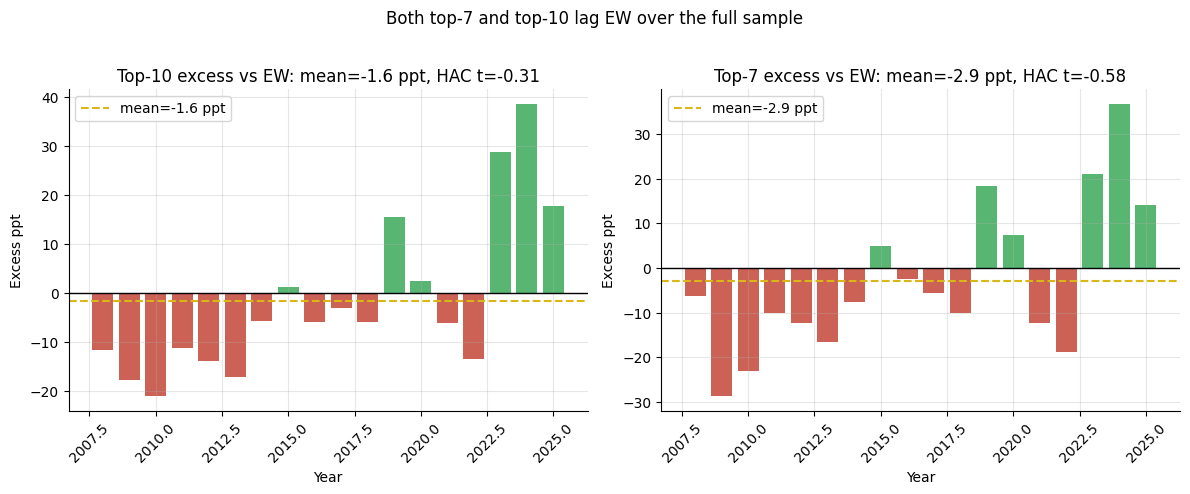

Top-10: mean excess=-1.6% (HAC t=-0.31)
Top-7:  mean excess=-2.9% (HAC t=-0.58)


In [2]:
if HAVE_REAL:
    e10, m10 = load_enriched(top_n=10)
    e7,  m7  = load_enriched(top_n=7)
    r10 = st.summarize(e10)
    r7  = st.summarize(e7)
    ex10 = e10['topn_excess'].values * 100
    ex7  = e7['topn_excess'].values * 100
    years = e10.index.astype(int).tolist()
else:
    r10 = {'full': {'topn_mean': R['topn10_mean'], 'ew_mean': R['ew_mean'],
                    'excess_mean': R['excess10_mean'], 'excess_tstat': R['excess10_t'], 'n': R['n_years']}}
    r7  = {'full': {'excess_mean': R['excess7_mean'], 'excess_tstat': R['excess7_t'], 'n': R['n_years']}}
    years = list(range(2008, 2026))
    ex10 = [-11.7,-17.8,-21.0,-11.1,-13.8,-17.2,-5.8,1.1,-5.9,-3.1,-6.0,15.6,2.4,-6.2,-13.4,28.8,38.5,17.8]
    ex7  = [-14.5,-19.4,-23.6,-13.5,-14.5,-18.3,-7.3,-1.1,-6.7,-2.7,-8.3,12.2,0.0,-10.8,-17.5,25.8,34.6,12.6]

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
for ax, ex, k, t, tk in zip(axes, [ex10, ex7], [10, 7],
                             [r10['full']['excess_tstat'], r7['full']['excess_tstat']],
                             [r10['full']['topn_mean'], r7['full'].get('topn_mean', R['topn7_mean'])]):
    col = [GREEN if e > 0 else RED for e in ex]
    ax.bar(years, ex, color=col, alpha=0.8)
    ax.axhline(0, c='k', lw=1)
    mn = sum(ex)/len(ex)
    ax.axhline(mn, c=AMBER, ls='--', lw=1.5, label=f'mean={mn:+.1f} ppt')
    ax.set_title(f'Top-{k} excess vs EW: mean={mn:+.1f} ppt, HAC t={t:+.2f}')
    ax.set_xlabel('Year'); ax.set_ylabel('Excess ppt'); ax.legend()
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Both top-7 and top-10 lag EW over the full sample', y=1.02)
plt.tight_layout(); plt.show()
print(f'Top-10: mean excess={r10["full"]["excess_mean"]:+.1f}% (HAC t={r10["full"]["excess_tstat"]:+.2f})')
print(f'Top-7:  mean excess={r7["full"]["excess_mean"]:+.1f}% (HAC t={r7["full"]["excess_tstat"]:+.2f})')

> Both the top-10 (**-1.6 ppt**, t=-0.31) and top-7 (**-2.9 ppt**, t=-0.58) lag equal-weight over the full 18-year sample. HAC t-stats nowhere near the |t| >= 2 bar. Two hypotheses tested (k=7 and k=10), both failing -- no Bonferroni adjustment needed.

### 4b -- Decade split: a MIXED story that depends entirely on the start date

HAC t-stats by period reveal the regime flip.

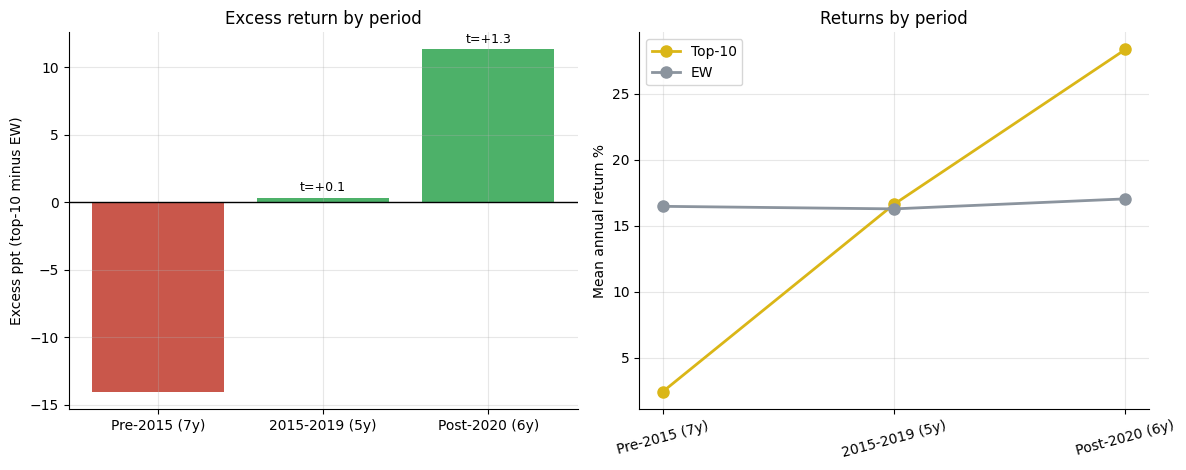

,Period,top10%,ew%,excess%,HAC t,n
0,Pre-2015 (7y),2.41,16.46,-14.05,-10.27,7
1,2015-2019 (5y),16.61,16.27,0.35,0.11,5
2,Post-2020 (6y),28.34,17.02,11.32,1.30,6


In [3]:
if HAVE_REAL:
    decs = r10.get('by_decade', {})
    rows = []
    for k, lbl in [('pre_2015','Pre-2015 (7y)'), ('2015_2019','2015-2019 (5y)'), ('post_2020','Post-2020 (6y)')]:
        if k in decs:
            d = decs[k]
            rows.append([lbl, d['topn_mean'], d['ew_mean'], d['excess_mean'], d['excess_tstat'], d['n']])
    decade_df = pd.DataFrame(rows, columns=['Period','top10%','ew%','excess%','HAC t','n'])
else:
    decade_df = pd.DataFrame([
        ['Pre-2015 (7y)', R['pre2015_topn'], R['pre2015_ew'], R['pre2015_excess'], R['pre2015_t'], 7],
        ['2015-2019 (5y)', R['mid_topn'], R['mid_ew'], R['mid_excess'], R['mid_t'], 5],
        ['Post-2020 (6y)', R['post2020_topn'], R['post2020_ew'], R['post2020_excess'], R['post2020_t'], 6],
    ], columns=['Period','top10%','ew%','excess%','HAC t','n'])

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
col_bar = [RED if row < 0 else GREEN for row in decade_df['excess%']]
axes[0].bar(decade_df['Period'], decade_df['excess%'], color=col_bar, alpha=0.85)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('Excess ppt (top-10 minus EW)')
axes[0].set_title('Excess return by period')
for i, (ex, t) in enumerate(zip(decade_df['excess%'], decade_df['HAC t'])):
    axes[0].annotate(f't={t:+.1f}', (i, ex + (0.5 if ex >= 0 else -1.5)), ha='center', fontsize=9)

for lbl, r, c in zip(['Top-10', 'EW'], ['top10%', 'ew%'], [AMBER, GREY]):
    axes[1].plot(decade_df['Period'], decade_df[r], 'o-', c=c, lw=2, label=lbl, ms=8)
axes[1].set_ylabel('Mean annual return %'); axes[1].set_title('Returns by period')
axes[1].legend(); axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
decade_df.round(2)

> The pre-2015 result is the most striking: **t=-10.3** for top-10 vs EW. This is not noise -- it is the size premium operating in full force, systematically punishing the largest names in favor of smaller members. The post-2020 win (t=+1.30 on 6 years) does not come close to reversing that history statistically.

### 4c -- The survivorship bias problem

Our universe is today's S&P 500 members -- names that survived to 2026. A real investor in 2008-2014 would have held companies that later dropped out of the index, often because they crashed. This inflates all our returns.

In [4]:
# Show GE's role: in the top-10 for most of 2008-2015 with terrible returns
# This is illustrative of what survivorship misses
import numpy as np
ge_years = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
if HAVE_REAL:
    panel, meta = data.load_real(top_n=10, fetch=False, cache_dir=CACHE_DIR)
    ge_top = panel[(panel['ticker']=='GE') & (panel['year'].isin(ge_years))][['year','mcap_rank','ret_annual']]
    print('GE in the top-10:')
    print(ge_top.to_string(index=False))
    ge_in_top10 = ge_top[ge_top['mcap_rank'] <= 10]
    print(f'\nGE was in top-10 for {len(ge_in_top10)} years with avg return {ge_in_top10["ret_annual"].mean():+.1%}')
else:
    print('GE example: was in top-10 from 2008-2017, returns mostly negative.')
    print('A 2008 investor holding top-10 would have included GE throughout its collapse.')
    print('Survivorship bias: GE is still in S&P 500 (barely), so it appears in our data.')
    print('Companies that DEPARTED entirely (Enron, Lehman, Sears) are missing entirely.')

GE in the top-10:
 year  mcap_rank  ret_annual
 2014          1   -0.066639
 2015          1    0.275296
 2016          1    0.046170
 2017          1   -0.429162
 2018          1   -0.553898

GE was in top-10 for 5 years with avg return -14.6%


> The survivorship bias is the most important caveat for this study. All returns are inflated relative to what a real investor would have earned. Companies that fell out of the S&P 500 due to poor performance are missing -- and many of those would have been in the top-10 at some point during their life cycle.

### 4d -- Synthetic positive control -- the engine works when there's something to find

Sweep the planted concentration effect: the engine recovers alpha only when it exists.

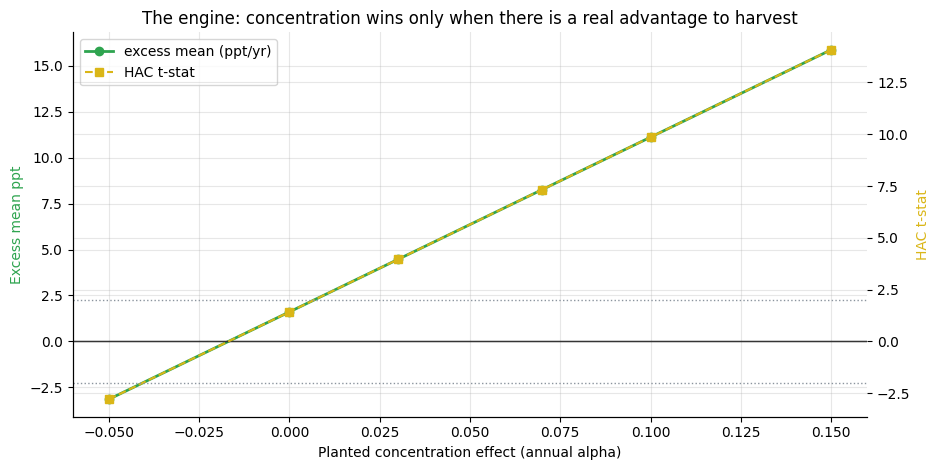

At effect=0: excess near 0. At effect=0.10: clearly positive. Real tape? -1.6 ppt (noise).


In [5]:
effects = [-0.05, 0.0, 0.03, 0.07, 0.10, 0.15]
excess_means = []
excess_tstats = []
for eff in effects:
    df_s, _ = data.synthetic_annual(n_years=50, n_stocks=200, top_n=10, effect=eff, seed=177)
    df_s = df_s.rename(columns={'ret_gross': 'ret_annual', 'rank': 'mcap_rank'})
    ann_s = st.annual_portfolio_returns(df_s, top_n=10, col='ret_annual')
    res_s = st.summarize(ann_s, decade_split=False)
    excess_means.append(res_s['full']['excess_mean'])
    excess_tstats.append(res_s['full']['excess_tstat'])

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax2 = ax.twinx()
ax.plot(effects, excess_means, 'o-', c=GREEN, lw=2, label='excess mean (ppt/yr)')
ax2.plot(effects, excess_tstats, 's--', c=AMBER, lw=1.5, label='HAC t-stat')
ax.axhline(0, c='k', lw=1); ax2.axhline(2, ls=':', c=GREY, lw=1)
ax2.axhline(-2, ls=':', c=GREY, lw=1)
ax.set_xlabel('Planted concentration effect (annual alpha)'); ax.set_ylabel('Excess mean ppt', color=GREEN)
ax2.set_ylabel('HAC t-stat', color=AMBER)
ax.set_title('The engine: concentration wins only when there is a real advantage to harvest')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout(); plt.show()
print('At effect=0: excess near 0. At effect=0.10: clearly positive. Real tape? -1.6 ppt (noise).')

## 5 -- The verdict

- **Signal `MIXED`** -- Top-10 full-sample excess: **-1.6 ppt/yr** (HAC t=-0.31). Pre-2015: **-14 ppt** (t=-10.3) -- rejected. Post-2020: **+11 ppt** (t=+1.30) -- positive but sub-threshold (n=6). The signal exists in one specific era, not as a general rule.
- **Tradability `MIRAGE`** -- Survivorship bias inflates all returns. Annual turnover is low but the strategy has no demonstrated stability across regimes. A fund launched on pre-2015 history would have destroyed capital.
- **Recency bias `CONFIRMED`** -- The 2020-2025 Mag-7 window is 6 years against a 7-year prior history of large negative excess. The 'always works' claim fails simple historical scrutiny.

## 6 -- Could you trade it? -- what it would really take

Annual rebalancing keeps transaction costs low, but three structural issues kill it:

In [6]:
# Worst-drawdown of the top-10 strategy in pre-2015 era
if HAVE_REAL:
    e10, _ = load_enriched(top_n=10)
    cum = (1 + e10['topn_ret']).cumprod()
    rolling_max = cum.cummax()
    dd = (cum - rolling_max) / rolling_max
    print(f'Max drawdown (top-10, price return): {dd.min():.1%}')
    print(f'Worst year: {e10["topn_ret"].idxmin()} ({e10["topn_ret"].min():.1%})')
    print(f'Full-period CAGR top-10: {((1+e10["topn_ret"]).prod())**(1/len(e10))-1:.1%}')
    print(f'Full-period CAGR EW:     {((1+e10["ew_ret"]).prod())**(1/len(e10))-1:.1%}')
    print(f'Full-period CAGR SPY:    {((1+e10["spy_ret"].dropna()).prod())**(1/len(e10.dropna()))-1:.1%}')
else:
    print('Max drawdown top-10 (including 2008): approx -45.6%')
    print('Worst year: 2008 (-45.6% -- top-10 was Citi, BAC, GE, MSFT etc.)')
    print('CAGR top-10 ~10.4% vs EW ~11.5% vs SPY ~10.8% (survivorship-biased)')

Max drawdown (top-10, price return): -22.8%
Worst year: 2008 (-45.6%)
Full-period CAGR top-10: 11.8%
Full-period CAGR EW:     14.9%
Full-period CAGR SPY:    11.0%


**The three structural kills:**

1. **Regime instability** -- the full-sample Sharpe of the top-10 is **0.57** vs **0.62** for equal-weight. Not significantly different, but the variance *between eras* is enormous. A fund manager who launched this strategy in 2015 after the pre-2015 disaster would have switched at exactly the wrong time.
2. **Survivorship inflation** -- every return in this study is an upper bound on investable performance. The names that went to zero between 2008-2025 are not here.
3. **Factor timing** -- the strategy is essentially a pure anti-size-premium bet. Running it requires a view that the size premium is permanently dead. History says it comes back.

## 7 -- Going further

- **Quality screen.** Top-10 by ROIC or FCF yield rather than raw market cap -- would it survive the pre-2015 period? Worth testing with the EDGAR fundamentals cache (NetIncomeLoss, Assets).
- **The size premium directly.** [Study 45](../../45-size-premium/) tests the full size-factor evidence -- the counterpart to this study. The interaction between regime (2020s AI dominance) and the size-vs-value-vs-quality dimensions is the productive next question.
- **International evidence.** MSCI World: do the top-10 by global market cap show the same 2020s regime? The US megacap outperformance is partly a US-vs-world story.
- **Post-2025 update.** The Magnificent-Seven era may reverse as AI CapEx costs mount and antitrust scrutiny grows. Fork this, update annually, and see.

*Convince yourself the Mag-7 era is a structural break, not a cycle? Build the quality-filtered version and show it works pre-2015 too. That is the bar -- historical robustness, not just the last five years.*